## Problem

Solve $$-u''(x) + αu(x)^3 + V(x)u(x) = f(x)$$ 
with $u(0) = u(1), u'(0) = u'(1)$

### We formulate an equivalent problem: 
 Minimize a functional for which $$-u''(x) + αu(x)^3 + V(x)u(x) - f(x)$$ is the gradient. 

*Why*: The optimality requires the gradient to be 0, so when we optimize the functional, we get a 0 gradient 'point', which means $-u''(x) + αu(x)^3 + V(x)u(x) - f(x) = 0$.

### What is the functional to optimize: 
$ E(u) = \int_0^1 [\frac{1}{2}u'(x)^2 + \frac{α}{4} u(x)^4 + \frac{V(x)}{2} u(x)^2 - f(x)u(x)] dx$


# Implementation

In [1]:
## Returns a N equally distanced points from a to b.
function linspace(a::Number, b::Number, N::Integer)
    h = (b-a)/N
    collect(a:h:b-h)
end

linspace (generic function with 1 method)

### Hyperparameters

In [2]:
# N - the space discretization bin count
N = 100

xx = linspace(0, 1, N)

100-element Vector{Float64}:
 0.0
 0.01
 0.02
 0.03
 0.04
 0.05
 0.06
 0.07
 0.08
 0.09
 0.1
 0.11
 0.12
 ⋮
 0.88
 0.89
 0.9
 0.91
 0.92
 0.93
 0.94
 0.95
 0.96
 0.97
 0.98
 0.99

### Problem Parameters

In [3]:
# u - unknown function to find
u_exact = sin.(2pi .*xx)

# α - a real
α = 1.

# V(x) - a function
V = 1.0 .+ 0.5 .* cos.(2π .* xx)

# f(x) - a function

100-element Vector{Float64}:
 1.5
 1.499013364214136
 1.496057350657239
 1.4911436253643444
 1.4842915805643155
 1.4755282581475768
 1.4648882429441257
 1.4524135262330098
 1.4381533400219317
 1.4221639627510076
 1.4045084971874737
 1.3852566213878945
 1.3644843137107059
 ⋮
 1.3644843137107057
 1.3852566213878947
 1.4045084971874737
 1.4221639627510076
 1.4381533400219317
 1.4524135262330098
 1.4648882429441255
 1.4755282581475768
 1.4842915805643155
 1.4911436253643444
 1.4960573506572388
 1.499013364214136

We use the u_exact and the other parameters to find an f that verifies the pde
$$f(x) = -u''(x) + αu(x)^3 + V(x)u(x) = 4π^2sin(2πx) + \alpha sin(2πx)^3 + sin(2πx) + 0.5cos(2πx)sin(2πx)$$

In [4]:
f = 4π^2*sin.(2π .* xx) + α .* u_exact.^3 + V .* u_exact

100-element Vector{Float64}:
   0.0
   2.5732417404937373
   5.137432226713647
   7.683509528420146
  10.202392164056418
  12.684973755413084
  15.122122801866846
  17.50468896034407
  19.823516957567467
  22.069468954786373
  24.233455843196673
  26.306477583065835
  28.2796723244954
   ⋮
 -28.279672324495415
 -26.306477583065835
 -24.233455843196683
 -22.06946895478636
 -19.823516957567467
 -17.504688960344048
 -15.122122801866881
 -12.684973755413093
 -10.202392164056443
  -7.683509528420149
  -5.137432226713664
  -2.573241740493733

### Visualizations

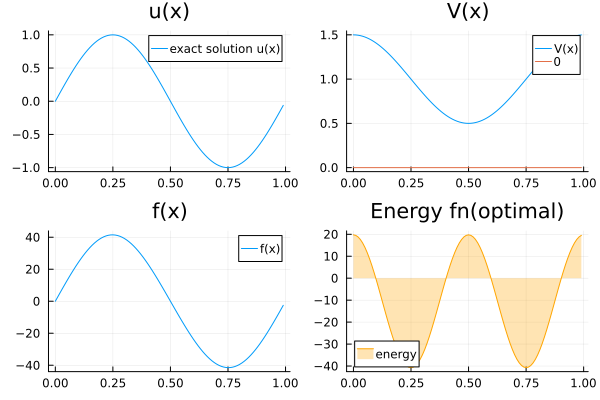

In [5]:
using Plots

u_plot = plot(xx, u_exact, label="exact solution u(x)")
V_plot = plot(xx, [V zeros(N)], 
    labels = ["V(x)" "0"]
)
f_plot = plot(xx, f, label = "f(x)")

## Energy functional
# E(u) = /int_0^1 [1/2 * u'(x)^2 + α/4 * u(x)^4 + V(x)/2 * u(x)^2 - f(x)u] dx
e = 1/2 * (2π .* cos.(2π .*xx)).^2 + α/4 .* u_exact.^4 + V./2 .* u_exact.^2 - f .* u_exact
E = sum(e)/N 
energy_plot = plot(xx, e, label="energy",
fillrange = 0, fillalpha = 0.3, fillcolor = :orange, color= :orange)


plot(u_plot, V_plot, f_plot, energy_plot, layout=(2,2), titles=["u(x)" "V(x)" "f(x)" "Energy fn(optimal)"])

## Optimization

*From here we suppose u in unknown and try to find a u that optimizes the functional*

Because of the discretization it comes back to a N dimensional optimization problem

**Astuces:**

u' can be calculated the following ways: 
- $u'(0) = u'(1)$ condition prompts us to have derivative equal from both ways approaching so we can have 
    $$ u'_i = \frac{u_{i+1} - u_{i-1} }{2h}$$
where the indexing wraps around modulo N
- **Spectral approach**
    We use the DFT, and the derivative in fourier space is easier to calculate

### Method One

#### Derivatives

In [6]:
## First derivative calculation matrix
function diff(N)
    # We need to calculate the u', which is just a linear operator in this case, so we construct a matrix to do that
    D = zeros(N, N)
    h = 1/N
    for i in 1:N
        D[i, mod(i, N)+1] = 1/2h
        D[i, mod(i-2, N)+1 ] = -1/2h
    end
    return D
end

diff (generic function with 1 method)

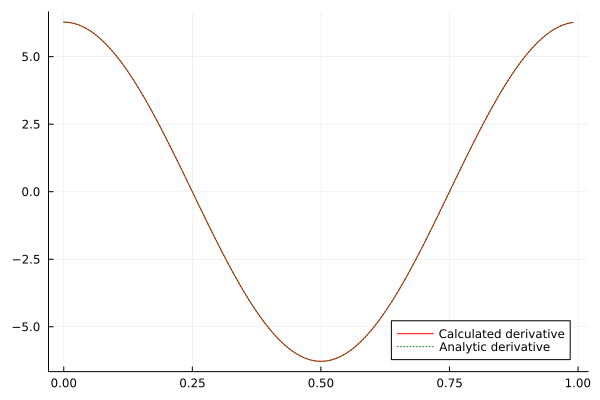

In [7]:
du_calc = diff(N) * u_exact
du_exact = 2π .* cos.(2π .* xx)
# du_calc_plot =plot(xx, du_calc)
# du_exact_plot = plot(xx, du_exact) 
du_plot = plot(xx, [du_calc du_exact], labels=["Calculated derivative" "Analytic derivative"], color=[:red :green], ls= [:solid :dot])
# plot(du_calc_plot, du_exact_plot, du_plot, layout = (2, 2))


In [8]:
## Second derivative calculation matrix
function diff2(N)
    D2 = zeros(N, N)
    h = 1/N
    for i in 1:N
        D2[i, i] = -2/(h^2)
        D2[i, mod(i, N)+1] = 1/(h^2)
        D2[i, mod(i-2, N) +1] = 1/(h^2)
    end
    return D2
end

diff2 (generic function with 1 method)

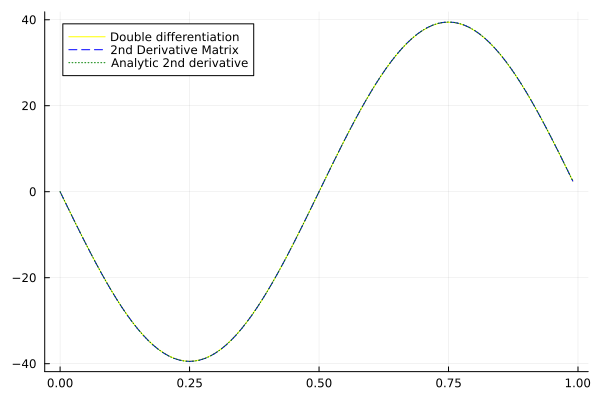

In [9]:
d2u = diff(N) * du_calc
d2u_form = diff2(N) * u_exact
d2u_exact = -4π^2 .* sin.(2π .* xx)
plot(xx, [d2u d2u_form d2u_exact], labels=["Double differentiation" "2nd Derivative Matrix" "Analytic 2nd derivative"], color=[:yellow :blue :green], ls= [:solid :dash :dot])


#### Newtons Method

In [10]:
struct SimpleParams
    N::Int64
    α::Float64
    V::Vector{Float64}
    f::Vector{Float64}
    D2::Matrix{Float64}
end


function F(u, p::SimpleParams)
    return -p.D2* u .+ p.α .* u.^3 + p.V .* u - p.f
end

F (generic function with 1 method)

In [11]:
function Newton_solve(p::SimpleParams, method, n_iter)
    u = zeros(p.N) # u_0
    for i in 1:n_iter
        res = F(u, p)
        J = method(F, p, u)
        step = J \ res
        u = u - step
    end
    return u
end

## A function that stores all the steps of Newton_solve
function Newton_solve_history(p::SimpleParams, method, n_iter)
    U = zeros(n_iter+1, p.N)
    for i in 1:n_iter
        res = F(U[i, :], p)
        J = method(F, p, U[i, :])
        step = J \ res
        U[i+1, :] = U[i, :] - step
    end
    return U
end

Newton_solve_history (generic function with 1 method)

#### Methods for calculating the Jacobian

**Finite differences**
$$ Jv = \frac{F (u + \varepsilon v) − F (u)}{\varepsilon}$$

In [12]:
function finite_differences(F, p, u; eps=1e-8) 
    J = zeros(p.N, p.N)
    for i in 1:p.N
        v = zeros(p.N)
        v[i] = 1
        J[:, i] = (F(u .+ eps * v, p) - F(u, p)) / eps
    end
    return J
end

finite_differences (generic function with 1 method)

**Forward Mode AD**

In [13]:
using Enzyme


function forward_AD(F, p, u)
    J = zeros(p.N, p.N)
    for i in 1:p.N
        v = zeros(p.N)
        v[i] = 1
        (col,) = autodiff(Forward, F, Duplicated(u, v), Const(p))
        J[:, i] = col
    end
    # J = jacobian(Forward, F, Duplicated(u), Const(p), chunk=Val(8))
    # print(J)
    return J
end

forward_AD (generic function with 1 method)

**Reverse Mode AD**

In [14]:
using Enzyme

function F_i(u, p, i, F)
    F(u, p)[i]
end

function backward_AD(F, p, u)
    J = zeros(p.N, p.N)
    for i in 1:p.N
        v = zeros(p.N)
        autodiff(Reverse, F_i, Active, Duplicated(u, v), Const(p), Const(i), Const(F))
        J[i, :] = v
    end
    # J = jacobian(Forward, F, Duplicated(u), Const(p), chunk=Val(8))
    # print(J)
    return J
end

backward_AD (generic function with 1 method)

#### Evaluating performance

**Visualizing newton steps**

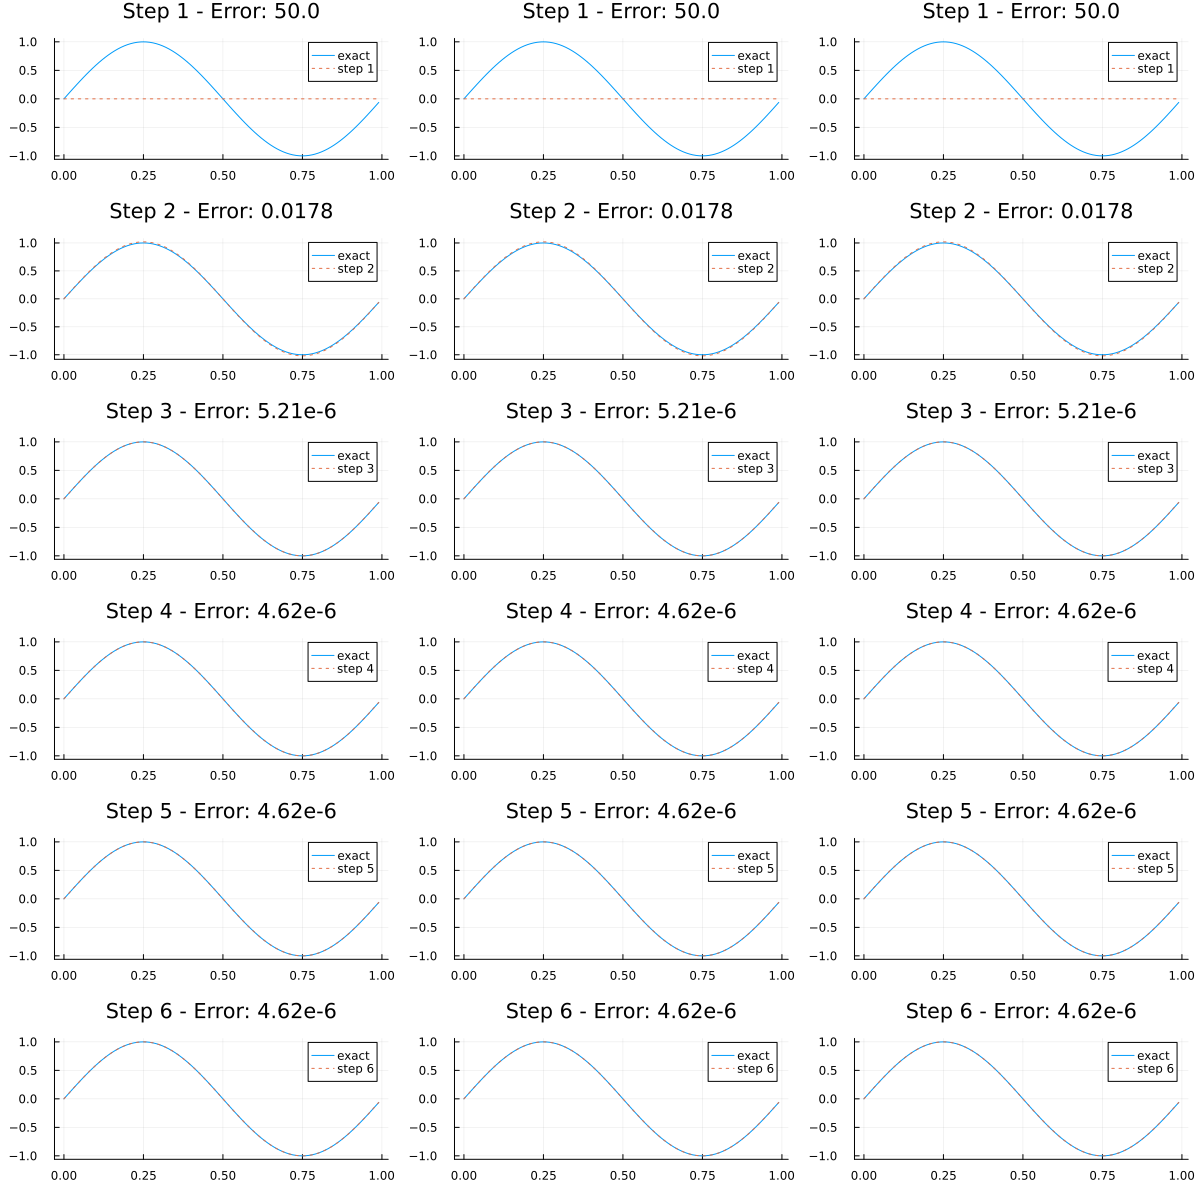

In [15]:
p_basic = SimpleParams(N, α, V, f, diff2(N))
steps = 5
solution_steps_fd = Newton_solve_history(p_basic, finite_differences, steps)
solution_steps_forwardAD = Newton_solve_history(p_basic, forward_AD, steps)
solution_steps_backwardAD = Newton_solve_history(p_basic, backward_AD, steps)

plots_fd = Vector{Any}(undef, steps+1)
plots_fad  = Vector{Any}(undef, steps+1)
plots_bad  = Vector{Any}(undef, steps+1)
for i in 1:steps+1
    error_fd = sum((solution_steps_fd[i, :] - u_exact).^2)
    plots_fd[i] = plot(xx, [u_exact, solution_steps_fd[i, :]], ls=[:solid :dot], label=["exact" "step $i"], title="Step $i - Error: $(round(error_fd, sigdigits=3))")

    error_fad = sum((solution_steps_forwardAD[i, :] - u_exact).^2)
    plots_fad[i] = plot(xx, [u_exact, solution_steps_forwardAD[i, :]], ls=[:solid :dot], label=["exact" "step $i"], title="Step $i - Error: $(round(error_fad, sigdigits=3))")

    error_bad = sum((solution_steps_backwardAD[i, :] - u_exact).^2)
    plots_bad[i] = plot(xx, [u_exact, solution_steps_backwardAD[i, :]], ls=[:solid :dot], label=["exact" "step $i"], title="Step $i - Error: $(round(error_bad, sigdigits=3))")
end

plot_fd = plot(plots_fd..., layout=(steps+1, 1), size=(400, 200*(steps+1)))
plot_fad = plot(plots_fad..., layout=(steps+1, 1), size=(400, 200*(steps+1)))
plot_bad =  plot(plots_bad..., layout=(steps+1, 1), size=(400, 200*(steps+1)))
plot(plot_fd, plot_fad, plot_bad, layout= (1, 3), size=(1200, 200*(steps+1)))

**Timing**

In [16]:
p_basic = SimpleParams(N, α, V, f, diff2(N))

start = time_ns()
u_solve = Newton_solve(p_basic, finite_differences, 5)
# plot(xx, [u_solve, u_exact], ls=[:solid :dot])
time_fd = (time_ns()-start) / 1e9
start = time_ns()
u_forward = Newton_solve(p_basic, forward_AD, 5)
time_fad = (time_ns() - start) / 1e9

start = time_ns()
u_backward = Newton_solve(p_basic, backward_AD, 5)
time_bad = (time_ns() - start) / 1e9
# plot(xx, [u_solve, u_forward], ls=[:solid :dot])
# Newton_solve(α, V, f, N,  method, n_iter)
println("Execution times")
println("Finite Differences: ", time_fd)
println("Forward AD: ", time_fad)
println("Backward AD: ", time_bad)
println("Error euclidean norm")
println("Finite differences: ", sum((u_solve - u_exact).^2))
println("Forward AD: ", sum((u_forward - u_exact).^2))
println("Backward AD: ", sum((u_backward - u_exact).^2))
# sum((u_solve - u_exact).^2) < sum((u_forward - u_exact).^2)


Execution times
Finite Differences: 0.043703163
Forward AD: 0.021992755
Backward AD: 0.031338041
Error euclidean norm
Finite differences: 4.62159297265057e-6
Forward AD: 4.621592972636068e-6
Backward AD: 4.621592972773436e-6


**Scaling**

One iteration solve comparison
N=5
Error Finite differences: 0.06380701472632969
Error Forward mode0.06380701003016317
Error Backward mode0.06380701003016317
N=10
Error Finite differences: 0.013440003564842694
Error Forward mode0.01344000611450969
Error Backward mode0.01344000611450969
N=100
Error Finite differences: 0.0178011948355281
Error Forward mode0.017801172294818837
Error Backward mode0.017801172294818837
N=500
Error Finite differences: 0.08607131383274215
Error Forward mode0.08607137941648337
Error Backward mode0.08607137941648337
5 Iterations
N=5
Error Finite differences: 0.04187686752266348
Error Forward mode0.04187686752266348
Error Backward mode0.04187686752266348
N=10
Error Finite differences: 0.004766914956810168
Error Forward mode0.004766914956810118
Error Backward mode0.004766914956810142
N=100
Error Finite differences: 4.62159297265057e-6
Error Forward mode4.621592972636068e-6
Error Backward mode4.621592972773436e-6
N=500
Error Finite differences: 3.696163270441733e-8

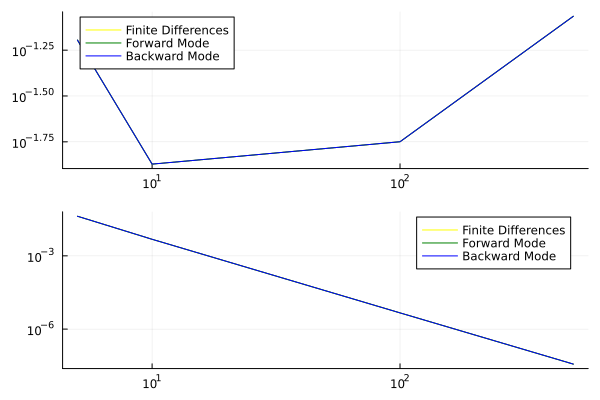

In [17]:
function create_params(N)
    xx = linspace(0, 1, N)

    u_exact = sin.(2pi .* xx)
    # α - a real
    α = 1.
    # V(x) - a function
    V = 1.0 .+ 0.5 .* cos.(2π .* xx)
    #f(x) - a function
    f = 4π^2*sin.(2π .* xx) + α .* u_exact.^3 + V .* u_exact
    
    return SimpleParams(N, α, V, f, diff2(N))
end

N_test = [5, 10, 100, 500]
p_test = map(create_params, N_test)

errs_1iter = zeros(length(N_test), 3)
errs_5iter = zeros(length(N_test), 3)

i = 1
println("One iteration solve comparison")
for p in p_test
    # run newton one iteration
    u_fd = Newton_solve(p, finite_differences, 1)
    u_fad = Newton_solve(p, forward_AD, 1)
    u_bad = Newton_solve(p, backward_AD, 1)
    xx = linspace(0, 1, p.N)
    u = sin.(2pi .* xx)
    err_fd = sum((u_fd .- u).^2)
    err_fad = sum((u_fad .- u).^2)
    err_bad = sum((u_bad .- u).^2)

    errs_1iter[i,1] = err_fd
    errs_1iter[i,2] = err_fad
    errs_1iter[i, 3] = err_bad
    i+=1
    println("N=",p.N)
    println("Error Finite differences: ", err_fd)
    println("Error Forward mode", err_fad)
    println("Error Backward mode", err_bad)
end
println("5 Iterations")

i = 1
for p in p_test
    # run newton one iteration
    u_fd = Newton_solve(p, finite_differences, 5)
    u_fad = Newton_solve(p, forward_AD, 5)
    u_bad = Newton_solve(p, backward_AD, 5)
    xx = linspace(0, 1, p.N)
    u = sin.(2pi .* xx)
    err_fd = sum((u_fd .- u).^2)
    err_fad = sum((u_fad .- u).^2)
    err_bad = sum((u_bad .- u).^2)
    errs_5iter[i,1] = err_fd
    errs_5iter[i,2] = err_fad
    errs_5iter[i,3] = err_bad
    i+=1
    println("N=",p.N)
    println("Error Finite differences: ", err_fd)
    println("Error Forward mode", err_fad)
    println("Error Backward mode", err_bad)
end
plot1 = plot(N_test, [errs_1iter[:, 1] errs_1iter[:, 2] errs_1iter[:, 3]], color = [:yellow :green :blue], label = ["Finite Differences" "Forward Mode" "Backward Mode"], xscale=:log10, yscale=:log10)
plot2 = plot(N_test, [errs_5iter[:, 1] errs_5iter[:, 2] errs_5iter[:, 3]], color = [:yellow :green :blue], label = ["Finite Differences" "Forward Mode" "Backward Mode"], xscale=:log10, yscale=:log10)

plot(plot1, plot2, layout=(2, 1))

### Spectral Method

The key idea of this method is that we use the fact that the solution is periodic, and for a periodic function we can calculate the derivative more easily after a fourier transform, it becomes just a multiplication!

In [18]:
using FFTW

# const ks_cache = Dict{Int, Vector{Float64}}()

# function get_ks(N)
#     get!(ks_cache, N) do
#         2π .* fftfreq(N, N)
#     end
# end

function diff_fourier(u, ks)
    u_trans = fft(u)
    real(ifft(im .* ks .* u_trans))
end

function diff2_fourier(u, ks)
    real(ifft(- ks.^2 .* fft(u)))
end

diff2_fourier (generic function with 1 method)

In [19]:
ks = 2π .* fftfreq(N, N)

xx = linspace(0, 1, N)
u_exact = sin.(2pi .* xx)
du_four = diff_fourier(u_exact, ks)
du_calc = diff(N) * u_exact
du_exact = 2π .* cos.(2π .* xx)
println("First derivative approximation error comparison")
println("Fourier approx error: ", sum((du_exact - du_four).^2))
println("Discrete approx error: ", sum((du_exact - du_calc).^2))


First derivative approximation error comparison
Fourier approx error: 1.4652318325491715e-25
Discrete approx error: 0.0008542308670755463


In [20]:
xx = linspace(0, 1, N)
u_exact = sin.(2pi .* xx)
du2_four = diff2_fourier(u_exact, ks)
du2_calc = diff2(N) * u_exact
du2_exact = -4π^2 .* sin.(2π .* xx)

println("Second derivative approximation error comparison")
println("Fourier approx error: ", sum((du2_exact - du2_four).^2))
println("Discrete approx error: ", sum((du2_exact - du2_calc).^2))

ks

Second derivative approximation error comparison
Fourier approx error: 1.4996115248348653e-20
Discrete approx error: 0.008432030289000745


100-element Frequencies{Float64}:
   0.0
   6.283185307179586
  12.566370614359172
  18.84955592153876
  25.132741228718345
  31.41592653589793
  37.69911184307752
  43.982297150257104
  50.26548245743669
  56.548667764616276
  62.83185307179586
  69.11503837897544
  75.39822368615503
   ⋮
 -75.39822368615503
 -69.11503837897544
 -62.83185307179586
 -56.548667764616276
 -50.26548245743669
 -43.982297150257104
 -37.69911184307752
 -31.41592653589793
 -25.132741228718345
 -18.84955592153876
 -12.566370614359172
  -6.283185307179586

### Revised Newton method

In [ ]:
struct FourierParams
    N::Int64
    α::Float64
    V::Vector{Float64}
    f::Vector{Float64}
    Ks::Vector{Float64}
end


function F_fourier(u, p::FourierParams)
    return -diff2_fourier(u, p.Ks) + p.α .* u.^3 + p.V .* u - p.f
end

function create_fparams(N)
    xx = linspace(0, 1, N)

    u_exact = sin.(2pi .* xx)
    # α - a real
    α = 1.
    # V(x) - a function
    V = 1.0 .+ 0.5 .* cos.(2π .* xx)
    #f(x) - a function
    f = 4π^2*sin.(2π .* xx) + α .* u_exact.^3 + V .* u_exact
    
    return FourierParams(N, α, V, f,  collect(2π .* fftfreq(N, N)))
end

maximum(abs.(F_fourier(u_exact, create_fparams(N))))

3.389644120943558e-11

Calculating now the Jacobian we will get a dense matrix, so solving it directly will be very computationally difficult
We opt for the following approach:

The only way we use the J matrix is to calculate $J^-1res$, or in other words 
find delta u such that
$$J \delta u = res(u)$$

having in mind that J is the jacobian, we find that J is the operator 
$$J(u) \delta u = -\delta u'' + 3 \alpha u^2 \delta u + V \delta u$$

we can consider the function 
$$f: \delta u \mapsto -\delta u'' + 3 \alpha u^2 \delta u + V \delta u$$

As the jacobian rests a linear operator, this function is also a linear map, we can use a Krylov method to solve for $f(x) = res(u)$

In [22]:
using Krylov, LinearOperators

function Newton_solve_fourier(p::FourierParams, n_iter; verbose=false, tol=1e-16)
    u = zeros(p.N) # u_0
    for i in 1:n_iter
        res = F_fourier(u, p)
        L = (result, du) -> result .= -diff2_fourier(du, p.Ks) + 3 * p.α .* u .^2 .* du .+ p.V .* du
        op = LinearOperator(Float64, p.N, p.N, true, true, L)
        step, stats = cg(op, res)
        if(verbose)
            println("Iteration: ", i,",\n stats: ", stats )
        end
        u = u - step
        if(sum(step.^2)<tol)
            if(verbose)
                println("Took ", i, "iterations to converge")
            end
            return u
        end
    end
    return u
end

Newton_solve_fourier (generic function with 1 method)

In [23]:
Newton_solve_fourier(create_fparams(100), 10, verbose=true)

Iteration: 1,
 stats: SimpleStats
 niter: 12
 solved: true
 inconsistent: false
 indefinite: false
 npcCount: 0
 residuals: []
 Aresiduals: []
 κ₂(A): []
 allocation timer: 2.05μs
 timer: 131.52ms
 status: solution good enough given atol and rtol

Iteration: 2,
 stats: SimpleStats
 niter: 53
 solved: true
 inconsistent: false
 indefinite: false
 npcCount: 0
 residuals: []
 Aresiduals: []
 κ₂(A): []
 allocation timer: 0.37μs
 timer: 883.08μs
 status: solution good enough given atol and rtol

Iteration: 3,
 stats: SimpleStats
 niter: 50
 solved: true
 inconsistent: false
 indefinite: false
 npcCount: 0
 residuals: []
 Aresiduals: []
 κ₂(A): []
 allocation timer: 1.22μs
 timer: 770.55μs
 status: solution good enough given atol and rtol

Iteration: 4,
 stats: SimpleStats
 niter: 0
 solved: true
 inconsistent: false
 indefinite: false
 npcCount: 0
 residuals: []
 Aresiduals: []
 κ₂(A): []
 allocation timer: 1.18μs
 timer: 1.55μs
 status: solution good enough given atol and rtol

Took 4itera

100-element Vector{Float64}:
  7.164808642262357e-14
  0.0627905195304723
  0.12533323356651963
  0.18738131458911222
  0.24868988716934096
  0.30901699438036984
  0.36812455269090755
  0.4257792915722148
  0.4817536741097906
  0.5358267949880392
  0.5877852523025361
  0.6374239897599313
  0.6845471059410358
  ⋮
 -0.6845471059410257
 -0.6374239897599419
 -0.587785252302705
 -0.5358267949881316
 -0.48175367410975267
 -0.42577929157206085
 -0.3681245526908451
 -0.3090169943803394
 -0.24868988716940196
 -0.18738131458920915
 -0.12533323356662882
 -0.06279051953039624

One iteration solve comparison

N=5
Error Finite differences: 0.06380701472632969
Error Forward mode: 0.06380701003016317
Error Backward mode: 0.06380701003016317
Error Fourier and CG: 0.0008633476863361582
N=10
Error Finite differences: 0.013440003564842694
Error Forward mode: 0.01344000611450969
Error Backward mode: 0.01344000611450969
Error Fourier and CG: 0.0017190040161831669
N=100
Error Finite differences: 0.0178011948355281
Error Forward mode: 0.017801172294818837
Error Backward mode: 0.017801172294818837
Error Fourier and CG: 0.017190040161831493
N=500
Error Finite differences: 0.08607131383274215
Error Forward mode: 0.08607137941648337
Error Backward mode: 0.08607137941648337
Error Fourier and CG: 0.08595020080915755
5 Iterations: 

N=5
Error Finite differences: 0.04187686752266348
Error Forward mode: 0.04187686752266348
Error Backward mode: 0.04187686752266348
Error Fourier and CG: 1.126019991108242e-21
N=10
Error Finite differences: 0.004766914956810168
Error Forward mode: 0

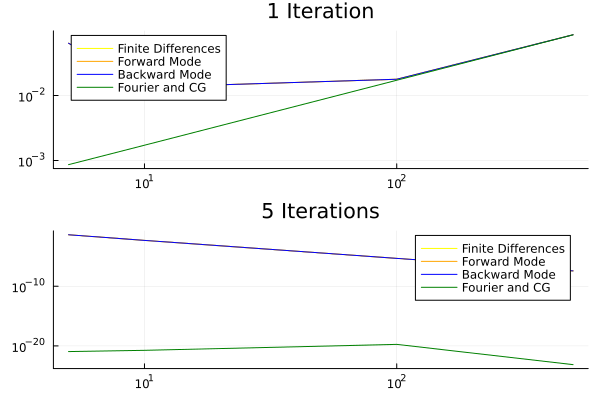

In [24]:
N_test = [5, 10, 100, 500]
p_test = map(create_params, N_test)


errs_1iter = zeros(length(N_test), 4)
errs_5iter = zeros(length(N_test), 4)

i = 1
println("One iteration solve comparison\n")
for p in p_test
    # run newton one iteration
    u_fd = Newton_solve(p, finite_differences, 1)
    u_fad = Newton_solve(p, forward_AD, 1)
    u_bad = Newton_solve(p, backward_AD, 1)
    u_fourier = Newton_solve_fourier(create_fparams(p.N), 1)
    xx = linspace(0, 1, p.N)
    u = sin.(2pi .* xx)
    err_fd = sum((u_fd .- u).^2)
    err_fad = sum((u_fad .- u).^2)
    err_bad = sum((u_bad .- u).^2)
    err_fourier = sum((u_fourier .- u).^2)

    errs_1iter[i,1] = err_fd
    errs_1iter[i,2] = err_fad
    errs_1iter[i, 3] = err_bad
    errs_1iter[i, 4] = err_fourier
    i+=1
    println("N=",p.N)
    println("Error Finite differences: ", err_fd)
    println("Error Forward mode: ", err_fad)
    println("Error Backward mode: ", err_bad)
    println("Error Fourier and CG: ", err_fourier)
end

println("5 Iterations: \n")

i = 1
for p in p_test
    # run newton one iteration
    u_fd = Newton_solve(p, finite_differences, 5)
    u_fad = Newton_solve(p, forward_AD, 5)
    u_bad = Newton_solve(p, backward_AD, 5)
    u_fourier = Newton_solve_fourier(create_fparams(p.N), 5)

    xx = linspace(0, 1, p.N)
    u = sin.(2pi .* xx)
    err_fd = sum((u_fd .- u).^2)
    err_fad = sum((u_fad .- u).^2)
    err_bad = sum((u_bad .- u).^2)
    err_fourier = sum((u_fourier .- u).^2)
    
    errs_5iter[i,1] = err_fd
    errs_5iter[i,2] = err_fad
    errs_5iter[i,3] = err_bad
    errs_5iter[i, 4] = err_fourier
    i+=1
    println("N=",p.N)
    println("Error Finite differences: ", err_fd)
    println("Error Forward mode: ", err_fad)
    println("Error Backward mode: ", err_bad)
    println("Error Fourier and CG: ", err_fourier)
end
plot1 = plot(N_test, [errs_1iter[:, 1] errs_1iter[:, 2] errs_1iter[:, 3] errs_1iter[:, 4]], color = [:yellow :orange :blue :green], label = ["Finite Differences" "Forward Mode" "Backward Mode" "Fourier and CG"], xscale=:log10, yscale=:log10, title="1 Iteration")
plot2 = plot(N_test, [errs_5iter[:, 1] errs_5iter[:, 2] errs_5iter[:, 3] errs_5iter[:, 4]], color = [:yellow :orange :blue :green], label = ["Finite Differences" "Forward Mode" "Backward Mode" "Fourier and CG"], xscale=:log10, yscale=:log10, title="5 Iterations")

plot(plot1, plot2, layout=(2, 1))

The new method is orders of magnitude more accurate than the previous methods. Lets see how the error progresses through iterations for this method

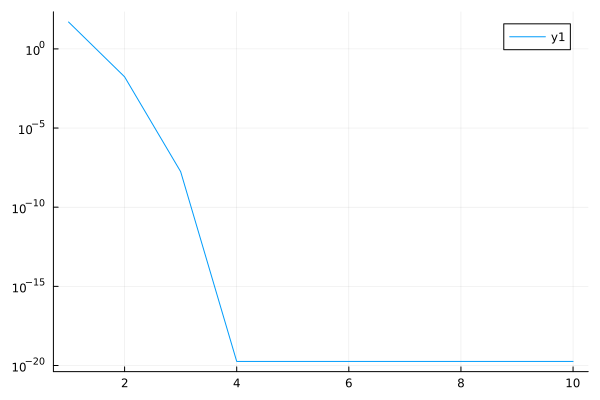

In [25]:
function Newton_solve_fourier_history(p::FourierParams, n_iter; verbose=false, tol=1e-16)
    U = zeros(n_iter+1, p.N)
    for i in 1:n_iter
        res = F_fourier(U[i, :], p)
        L = (res, du) -> res .= -diff2_fourier(du, p.Ks) + 3 * p.α .* U[i, :] .^2 .* du .+ p.V .* du
        op = LinearOperator(Float64, p.N, p.N, true, true, L)
        step, stats = cg(op, res)
        if(verbose)
            println("Iteration: ", i,",\n stats: ", stats )
        end
        U[i+1, :] = U[i, :] - step
    end
    return U
end

p = create_fparams(N)
u_fourier_history = Newton_solve_fourier_history(p, 10)

errors = zeros(10)
for i in 1:10
    errors[i]  = sum((u_fourier_history[i, :] - u_exact).^2)
end

plot(1:10, errors, yscale=:log10)

In [ ]:
using Krylov

function Newton_solve_fourier_preconditioned(p::FourierParams, n_iter; verbose=false, tol=1e-16)
    u = zeros(p.N) # u_0
    for i in 1:n_iter
        res = F_fourier(u, p)
        L = (result, du) -> result .= -diff2_fourier(du, p.Ks) + 3 * p.α .* u .^2 .* du .+ p.V .* du
        op = LinearOperator(Float64, p.N, p.N, true, true, L)
        c = sum(3 * p.α .* u .^2 .+ p.V) / N
        P = (out, v) -> out .= real(ifft(fft(v) ./ (p.Ks.^2 .+ c)))
        P_op = LinearOperator(Float64, p.N, p.N, true, true, P)

        # step, stats = cg(op, res)
        step, precond_stats = cg(op, res, M=P_op)
        if(verbose)
            _, stats = cg(op, res)
            println("Iteration: ", i,",\n stats: ", stats )
            println("Iteration: ", i,",\n Preconditioning stats: ", precond_stats )
        end
        u = u - step
        if(sqrt(sum(step.^2))<tol)
            if(verbose)
                println("Took ", i, "iterations to converge")
            end
            return u
        end
    end
    return u
end